In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from utils import get_hits, z_score

pd.set_option("display.max_columns", None)

In [8]:
# Convert to parquet
tsv_file = "sexism2 Recording3.tsv"
tsv_path = os.path.join("data", tsv_file)
file = tsv_path.split(".")[0] + ".parquet"
df = pd.read_csv(tsv_path, sep="\t", low_memory=False).to_parquet(file, index=False)

In [ ]:
# Read without unwanted columns
df = pd.read_parquet(file)
aoi_size = [col for col in df.columns if "AOI size" in col]
unwanted_cols = aoi_size + [
    "Client area position X (DACSpx)",
    "Client area position Y (DACSpx)",
    "Viewport position X",
    "Viewport position Y",
    "Viewport width",
    "Viewport height",
    "Full page width",
    "Full page height",
    "Mouse position X",
    "Mouse position Y",
]
cols_to_keep = [col for col in df.columns if col not in unwanted_cols]
df = pd.read_csv("data/sexism2 Data attention.tsv", sep="\t", low_memory=False, usecols=cols_to_keep)

# column groups
aoi_size = [col for col in df.columns if "AOI size" in col]
aoi_hit = [col for col in df.columns if "AOI hit" in col]
aois = aoi_size + aoi_hit
calibration = [col for col in df.columns if "calibration" in col] + [col for col in df.columns if "validation" in col]
cols = list(set(df.columns) - set(aois) - set(calibration))

part_col = "Participant name"
participants = df[part_col].unique().tolist()

texts = [t.split("[")[1].split()[0] for t in aoi_hit]
texts

# drop [nan, 'Unclassified', 'EyesNotFound']
df = df[df["Eye movement type"].isin(("Fixation", "Saccade"))]

# hits to int
df[aoi_hit] = df[aoi_hit].fillna(0).astype(int)

# calibration data
calibration_df = df[["Participant name"] + calibration].drop_duplicates()
df = df.drop(calibration, axis=1)

df = z_score(df, "Pupil diameter filtered", part_col)

text_hits = get_hits(df, texts, aoi_hit, part_col, normalize=True)

In [ ]:
# todo: is there a "text" column, else -> create it
# -> unique [text, participant] to check if they did all the texts.

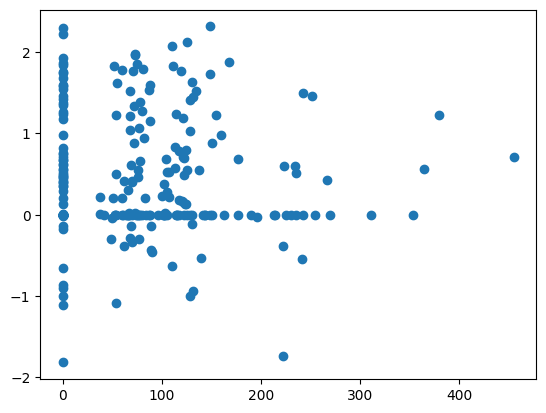

In [25]:
text = texts[1]
plt.scatter(text_hits[text]["hits"], text_hits[text]["z_pupil"])

In [ ]:
# Eye movement type	Eye movement event duration

In [ ]:
# df[df.Event.isna()]

In [ ]:
# df[~df['AOI hit [Text - tu]'].isna()]